In [1]:
import pandas as pd
import numpy as np
import json
import os
import random
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from konlpy.tag import Okt
from wordcloud import WordCloud
from collections import Counter

import torch
from transformers import pipeline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.metrics import classification_report, confusion_matrix
from lightgbm import LGBMClassifier
import optuna

import shap

# 한글 폰트 설정
font_path = './NanumGothic.ttf'
fontprop = fm.FontProperties(fname = font_path)
plt.rcParams['axes.unicode_minus'] = False

# 시드 고정 함수
def seed_everything(seed = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)
seed_everything()

# 문화 여가 생활에 대한 만족/불만족 원인 탐색

In [41]:
# ==================================================
# 문화 여가 현황 데이터
# ==================================================

# https://www.bigdata-culture.kr/bigdata/user/main.do
reason = pd.read_csv('satisfaction_dissatisfaction.csv', encoding = 'utf-8')

만족 응답 키워드 (상위 10개):
[('여유', 702), ('생활', 336), ('충분하다', 244), ('경제', 214), ('즐겁다', 148), ('비용', 146), ('스트레스', 141), ('여행', 134), ('주변', 127), ('만족', 125)]


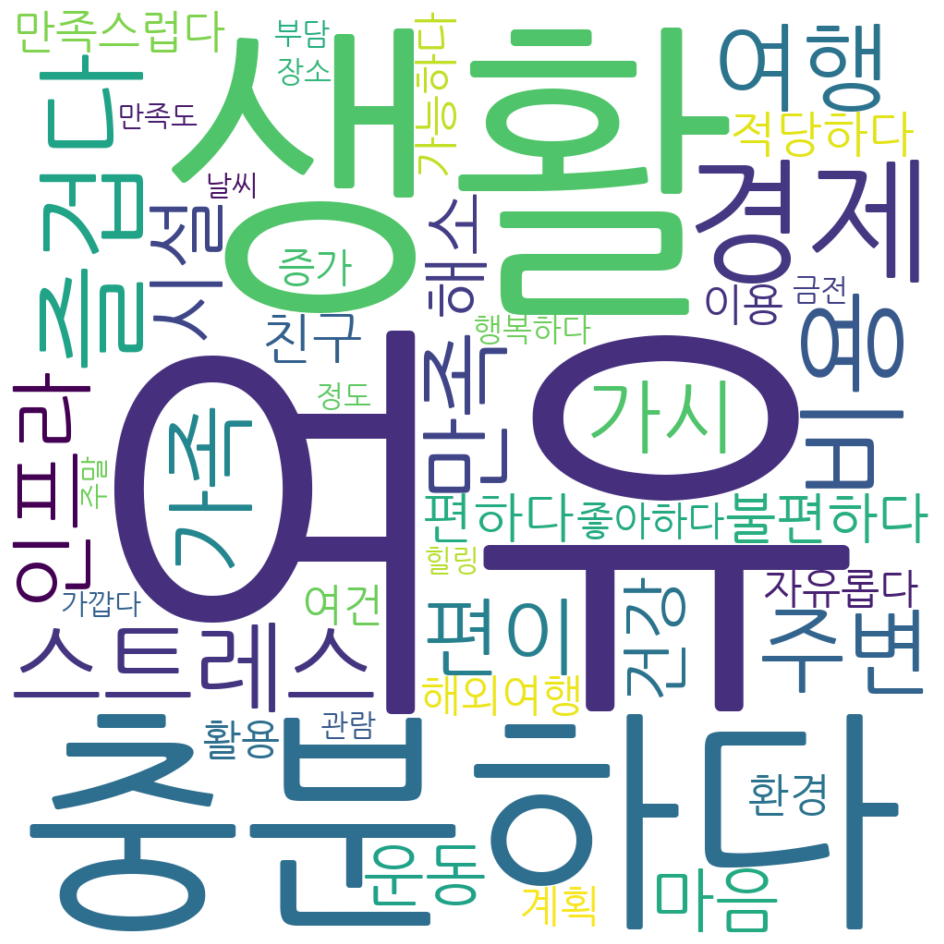

In [ ]:
# ==================================================
# 만족 응답 분석
# ==================================================

# 만족 응답
sat1 = reason[
    reason['LSR_CLTUR_ACT_WHOLE_SATSFC_VALUE'] == '만족하는 편이다'
]
sat2 = reason[
    reason['LSR_CLTUR_ACT_WHOLE_SATSFC_VALUE'] == '매우 만족한다'
]
sat = pd.concat(
    [sat1, sat2], ignore_index = True
)['LSR_CLTUR_ACT_SATSFC_IMPRTY_RESN_CN'].copy()

# WordCloud 전처리
sat_str = ' '.join(sat.astype(str))

# 형태소 분석기
sat_okt = Okt()
sat_morphs = sat_okt.pos(sat_str, stem = True)

# 길이가 2 이상인 명사/형용사 키워드 추출
sat_keywords = [
    word for word, pos in sat_morphs if pos in ['Noun', 'Adjective'] and len(word) > 1
]

# 불용어 제거 (Hard-Coded)
sat_stopwords = [
    '있다', '하다', '되다', '같다', '없다', '좋다', '사람',
    '이유', '활동', '문화', '여가', '경우', '생각', '시간',
    '통해', '매우', '다양하다', '때문', '원하다', '만족하다', '많다'
]

sat_keywords = [
    word for word in sat_keywords if word not in sat_stopwords
]

# 상위 10개 키워드 추출
sat_counts = Counter(sat_keywords)
sat_keywords_top10 = sat_counts.most_common(10)

print('만족 응답 키워드 (상위 10개):')
print(sat_keywords_top10)

# 워드 클라우드 객체
sat_wordcloud = WordCloud(
    font_path = font_path,
    width = 1000,
    height = 1000,
    background_color='white',
    max_words = 45
)

sat_wordcloud = sat_wordcloud.generate_from_frequencies(sat_counts)

# 워드 클라우드 출력
plt.figure(figsize=(12, 12))
plt.imshow(sat_wordcloud, interpolation = 'bilinear')
# plt.title('만족 응답 키워드', fontproperties = fontprop, size = 18)
plt.axis('off')
plt.show()

불만족 응답 키워드 (상위 10개):
[('여유', 597), ('경제', 469), ('생활', 433), ('부족', 433), ('특별하다', 331), ('변화', 310), ('보통', 249), ('부족하다', 247), ('크게', 210), ('비슷하다', 209)]


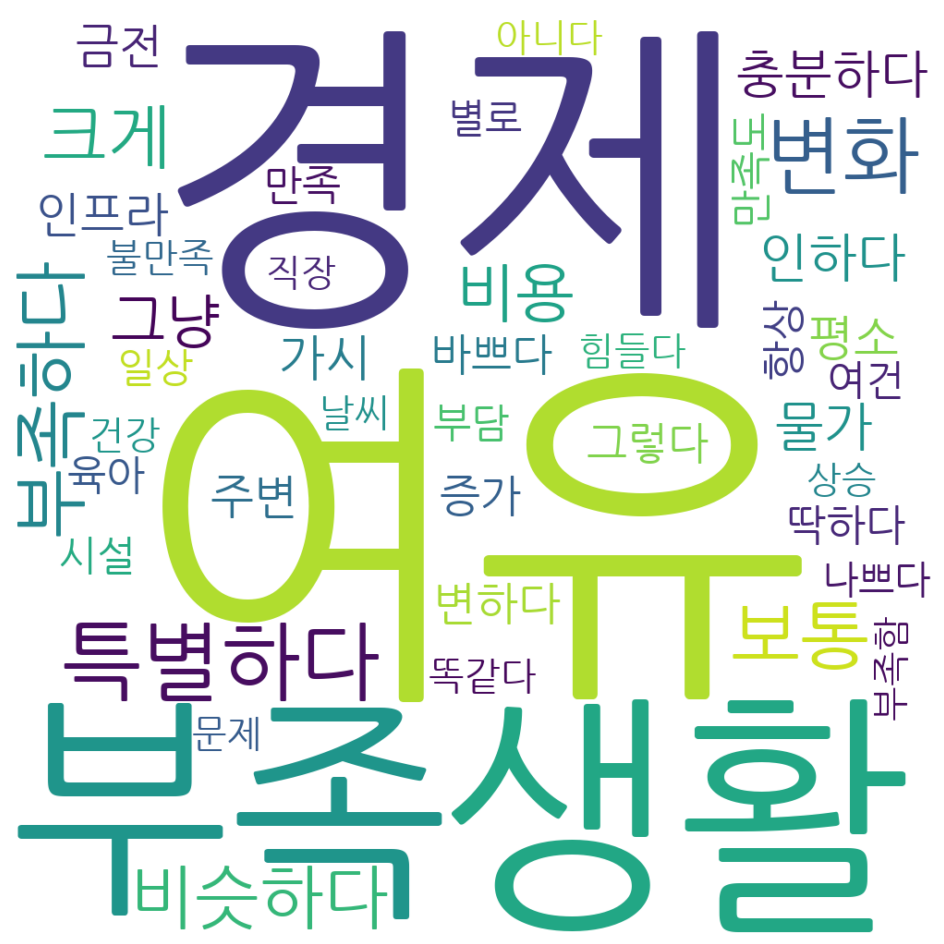

In [43]:
# ==================================================
# 불만족 응답 분석
# ==================================================

# 불만족 응답
dis1 = reason[
    reason['LSR_CLTUR_ACT_WHOLE_SATSFC_VALUE'] == '보통이다'
]
dis2 = reason[
    reason['LSR_CLTUR_ACT_WHOLE_SATSFC_VALUE'] == '불만족하는 편이다'
]
dis3 = reason[
    reason['LSR_CLTUR_ACT_WHOLE_SATSFC_VALUE'] == '매우 불만족한다'
]
dis = pd.concat(
    [dis1, dis2, dis3], ignore_index = True
)['LSR_CLTUR_ACT_SATSFC_IMPRTY_RESN_CN'].copy()

# WordCloud 전처리
dis_str = ' '.join(dis.astype(str))

# 형태소 분석기
dis_okt = Okt()
dis_morphs = dis_okt.pos(dis_str, stem = True)

# 길이가 2 이상인 명사/형용사 키워드 추출
dis_keywords = [
    word for word, pos in dis_morphs if pos in ['Noun', 'Adjective'] and len(word) > 1
]

# 불용어 제거 (Hard-Coded)
dis_stopwords = [
    '있다', '하다', '되다', '같다', '없다', '좋다', '사람',
    '이유', '활동', '문화', '여가', '경우', '생각', '시간',
    '통해', '매우', '다양하다', '때문', '원하다', '만족하다','많다'
]

dis_keywords = [
    word for word in dis_keywords if word not in dis_stopwords
]

# 상위 10개 키워드 추출
dis_counts = Counter(dis_keywords)
dis_keywords_top10 = dis_counts.most_common(10)

print('불만족 응답 키워드 (상위 10개):')
print(dis_keywords_top10)

# 워드 클라우드 객체
dis_wordcloud = WordCloud(
    font_path = font_path,
    width = 1000,
    height = 1000,
    background_color='white',
    max_words = 45
)

dis_wordcloud = dis_wordcloud.generate_from_frequencies(dis_counts)

# 워드 클라우드 출력
plt.figure(figsize=(12, 12))
plt.imshow(dis_wordcloud, interpolation = 'bilinear')
# plt.title('불만족 응답 키워드', fontproperties = fontprop, size = 20)
plt.axis('off')
plt.show()

# 국내 특화 해외작 탐색

In [4]:
# ==================================================
# 국내 박스오피스 상위 300개 해외작 데이터
# ==================================================

# https://www.boxofficemojo.com/
# https://www.kobis.or.kr/kobis/business/stat/offc/findFormerBoxOfficeList.do
movie = pd.read_csv('top300_movie.csv', encoding = 'utf-8')

In [5]:
# ==================================================
# 국내 특화 해외작 정의
# ==================================================

# 세계 흥행 지수: 평균 세계 매출액 대비 개별 세계 매출액
movie['세계흥행지수'] = 100 * movie['세계매출액'] / movie['세계매출액'].mean()

# 국내 흥행 지수: 세계 매출액 대비 국내 매출액
movie['국내흥행지수'] = 100 * movie['국내매출액'] / movie['세계매출액']

# 흥행 유형 구분
q2_world = movie['세계흥행지수'].median()
q3_domestic = movie['국내흥행지수'].quantile(0.75)

def hit_quadrant(row):
    if row['세계흥행지수'] >= q2_world and row['국내흥행지수'] >= q3_domestic:
        return 'A (글로벌 동조)'
    elif row['세계흥행지수'] < q2_world and row['국내흥행지수'] >= q3_domestic:
        return 'B (국내 특화)'
    elif row['세계흥행지수'] >= q2_world and row['국내흥행지수'] < q3_domestic:
        return 'C (글로벌 의존)'
    else:
        return 'D (상대적 저성과)'
    
movie['유형'] = movie.apply(hit_quadrant, axis = 1)

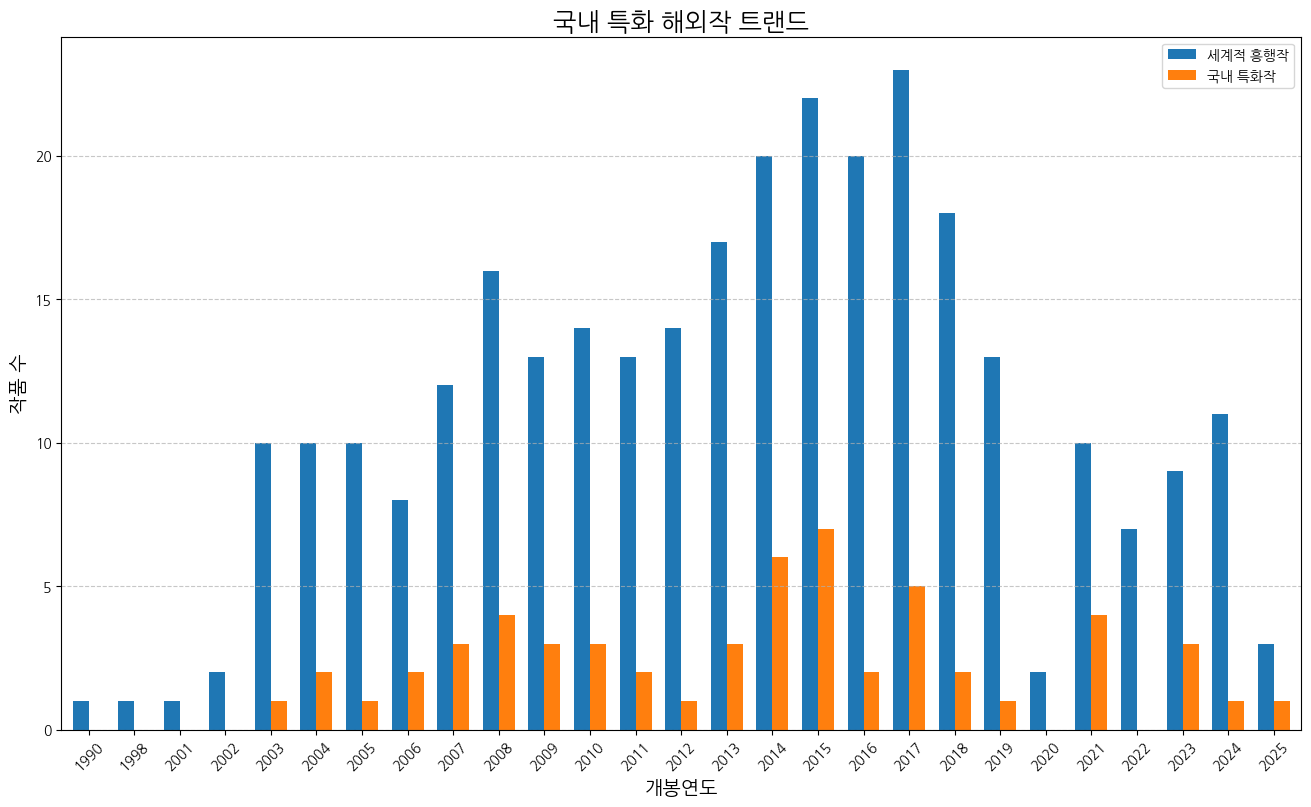

In [6]:
# ==================================================
# 연도별 국내 특화 해외작
# ==================================================

# 연도별 전체 흥행작 수
total_by_year = movie['개봉연도'].value_counts().sort_index()

# 연도별 국내 특화 해외작 수
domestic_by_year = movie[
    movie['유형'] == 'B (국내 특화)'
].copy()['개봉연도'].value_counts().sort_index()

# 데이터 프레임 변환
trend = pd.DataFrame({
    '세계적 흥행작': total_by_year,
    '국내 특화작': domestic_by_year
}).fillna(0)

# 그래프
fig, ax = plt.subplots(figsize=(16, 9))
trend[['세계적 흥행작', '국내 특화작']].plot(kind = 'bar', ax = ax, width = 0.7)
ax.set_ylabel('작품 수', fontproperties = fontprop, fontsize = 14)
ax.set_xlabel('개봉연도', fontproperties = fontprop, fontsize = 14)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.title('국내 특화 해외작 트랜드', fontproperties = fontprop, fontsize = 18)
plt.legend(prop = fontprop, fontsize = 14)
plt.xticks(rotation = 45, fontproperties = fontprop, fontsize = 10)
plt.yticks(fontproperties = fontprop, fontsize = 10)
plt.show()

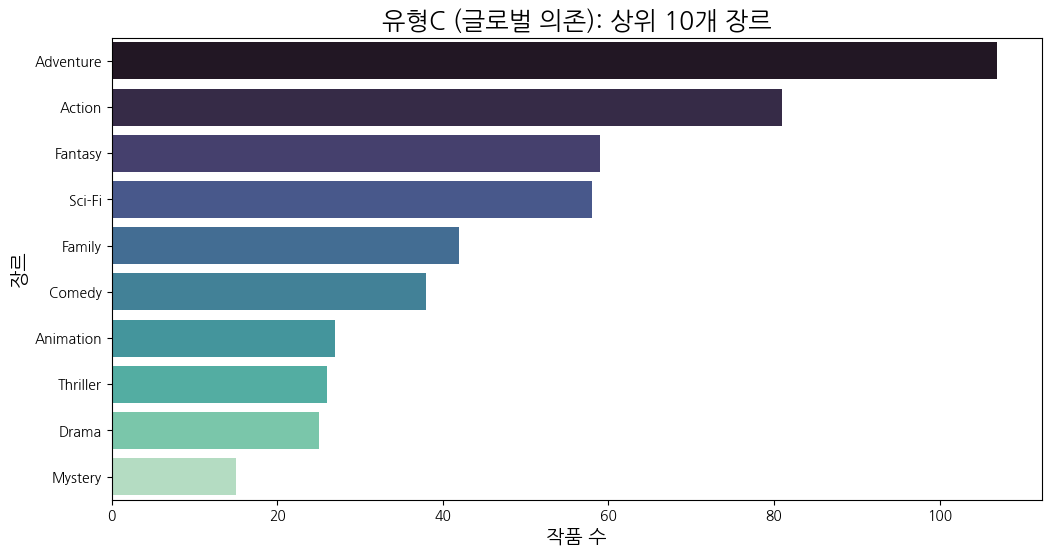

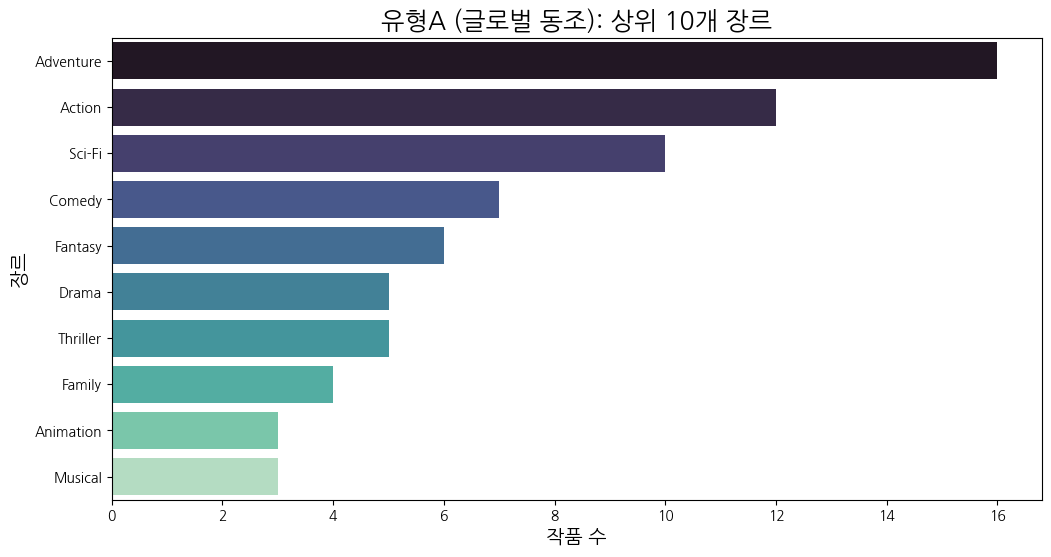

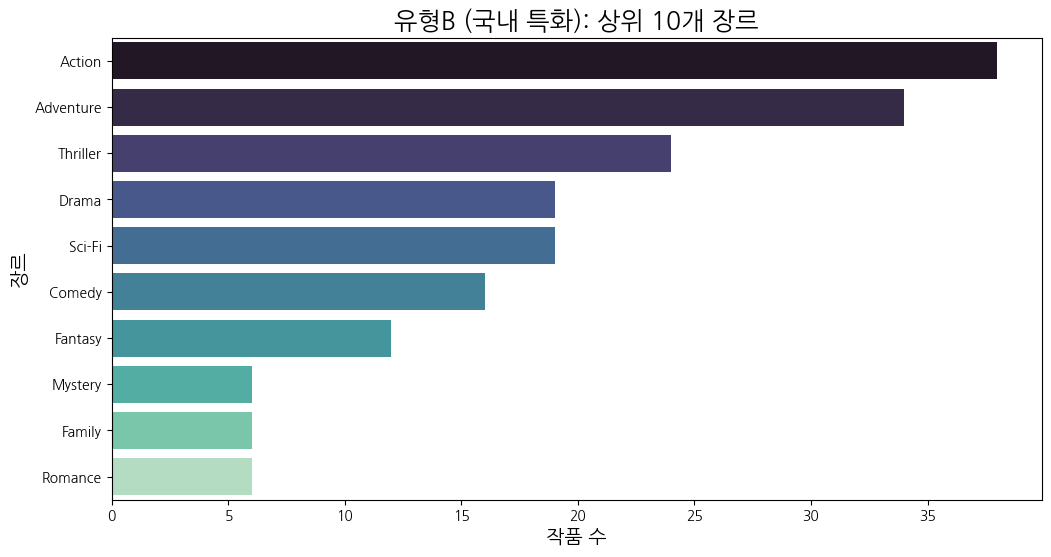

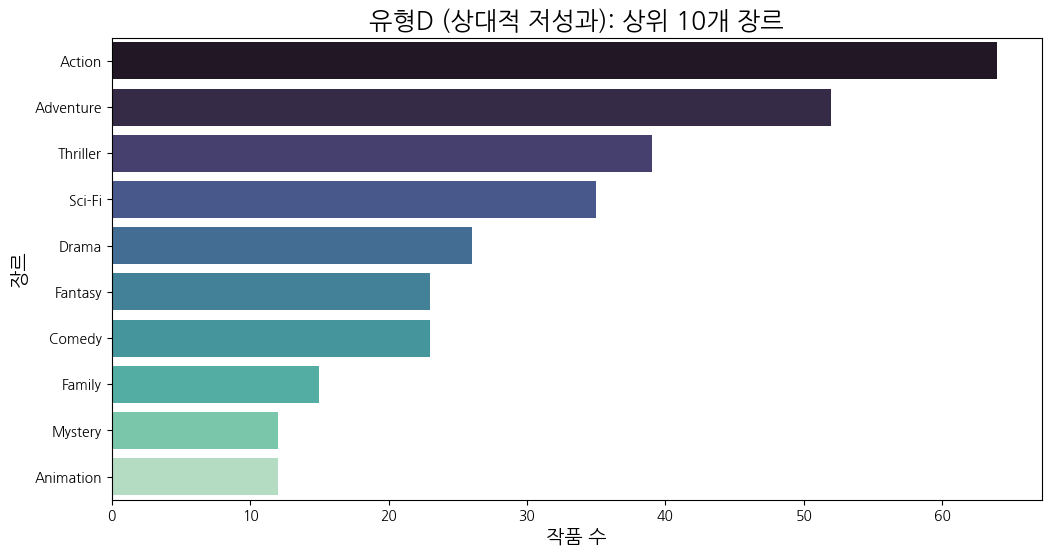

In [12]:
# ==================================================
# 장르 분석
# ==================================================

for i in list(movie['유형'].unique()):
    genre = movie[
        movie['유형'] == f'{i}'
    ].copy()
    genre =  (
        genre['장르']
        .apply(lambda x: x.split())
        .explode()
        .value_counts()
    )

    # 상위 10개 장르
    genre_counts = genre.head(10)

    # 그래프
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x = genre_counts.values,
        y = genre_counts.index,
        palette = 'mako',
        hue = genre_counts.index,
        legend = False
    )
    plt.title(f'유형{i}: 상위 10개 장르', fontproperties = fontprop, fontsize = 18)
    plt.xlabel('작품 수', fontproperties = fontprop, fontsize = 14)
    plt.ylabel('장르', fontproperties = fontprop, fontsize = 14)
    plt.xticks(fontproperties = fontprop, fontsize = 10)
    plt.yticks(fontproperties = fontprop, fontsize = 10)
    plt.show()

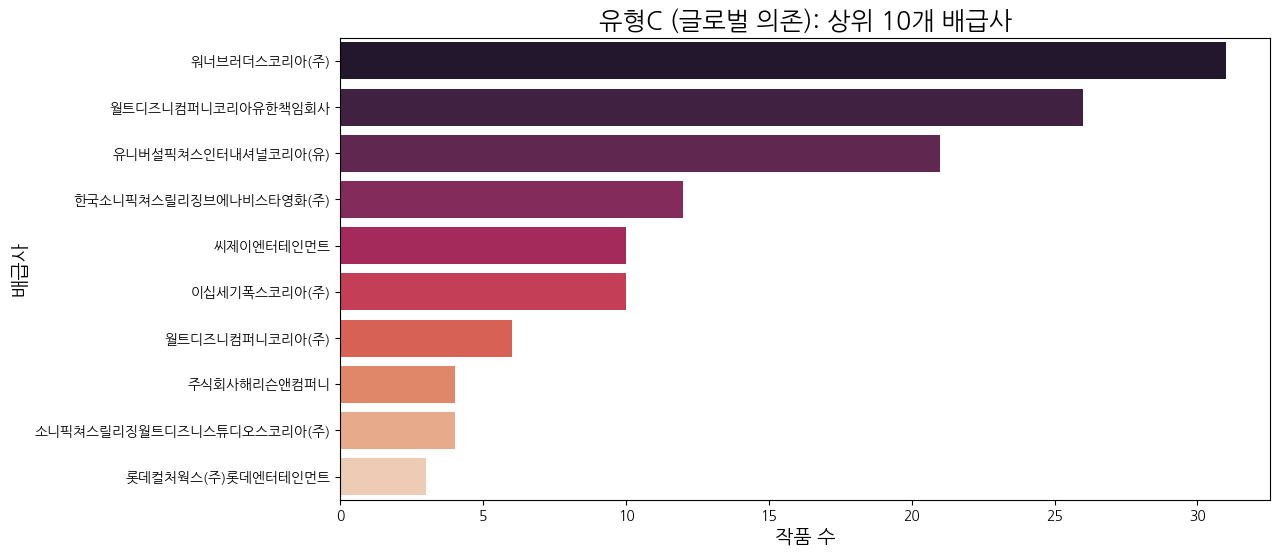

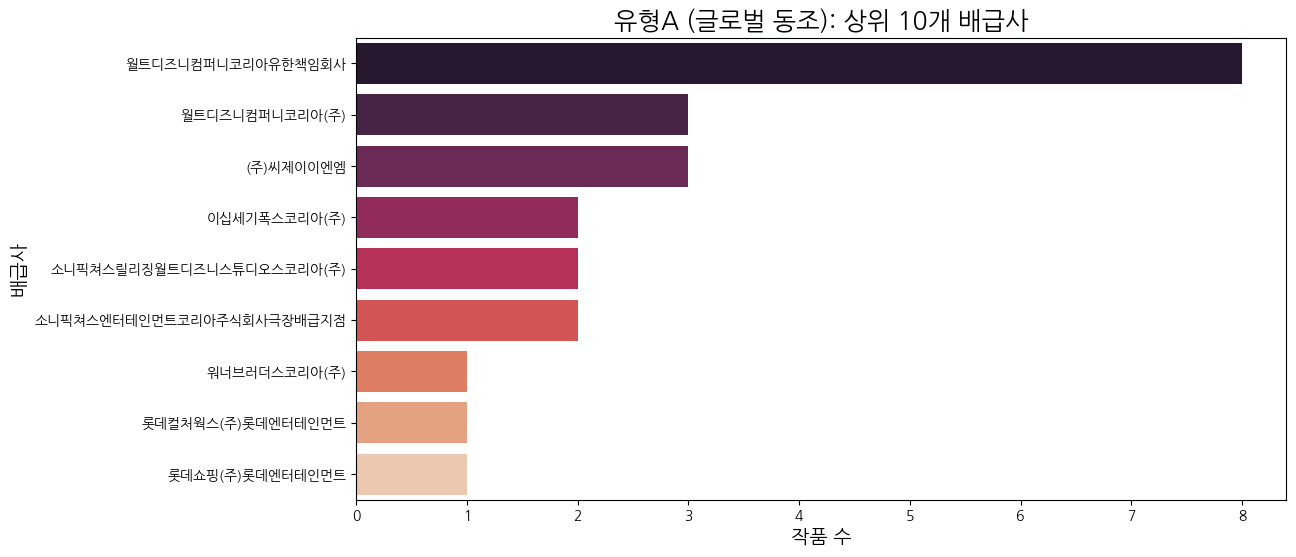

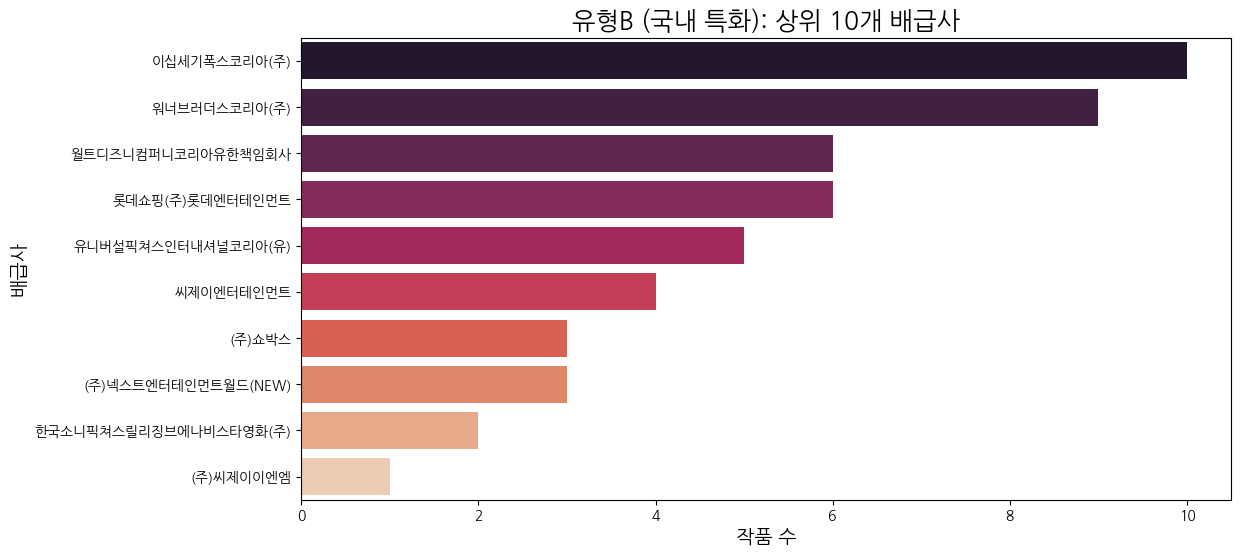

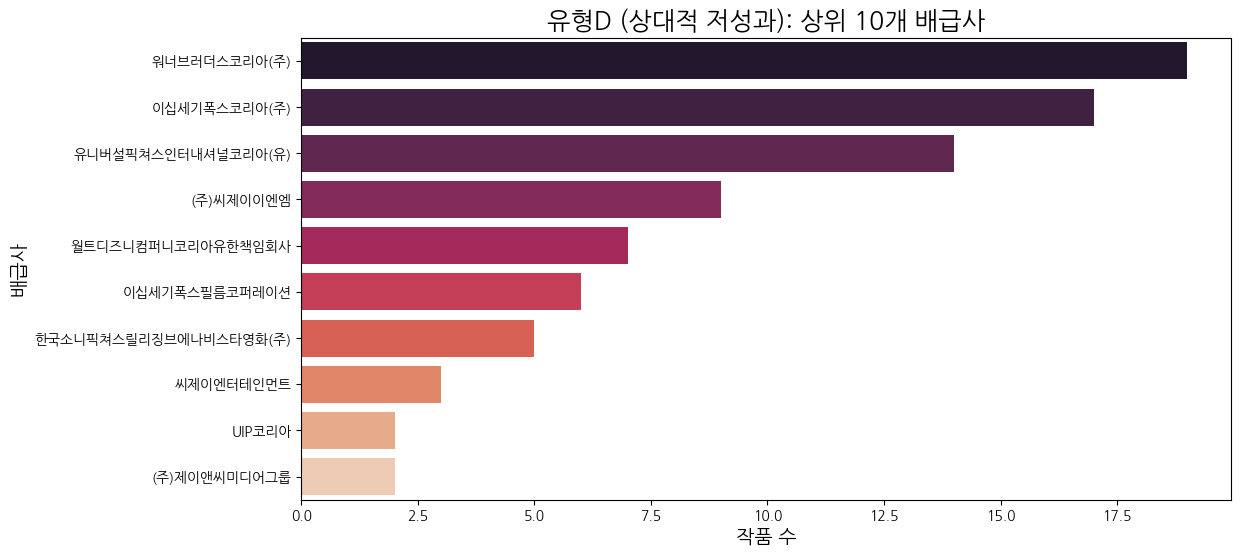

In [13]:
# ==================================================
# 국내 특화 해외작 배급사 분석
# ==================================================

for i in list(movie['유형'].unique()):
    distributor = movie[
        movie['유형'] == f'{i}'
    ].copy()
    distributor =  (
        distributor['배급사']
        .apply(lambda x: x.split())
        .explode()
        .value_counts()
    )

    # 상위 10개 장르
    distributor_counts = distributor.head(10)

    # 그래프
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x = distributor_counts.values,
        y = distributor_counts.index,
        palette = 'rocket',
        hue = distributor_counts.index,
        legend = False
    )
    plt.title(f'유형{i}: 상위 10개 배급사', fontproperties = fontprop, fontsize = 18)
    plt.xlabel('작품 수', fontproperties = fontprop, fontsize = 14)
    plt.ylabel('배급사', fontproperties = fontprop, fontsize = 14)
    plt.xticks(fontproperties = fontprop,fontsize = 10)
    plt.yticks(fontproperties = fontprop,fontsize = 10)
    plt.show()

In [59]:
# ==================================================
# 재사용을 위한 저장
# ==================================================

movie.to_csv('top300_movie_quadrant.csv', index = False, encoding = 'utf-8')

# Feature 생성

In [2]:
# ==================================================
# 리뷰 데이터
# ==================================================

# 영화 데이터
movie = pd.read_csv('top300_movie_quadrant.csv', encoding = 'utf-8')

# https://pedia.watcha.com/ko-KR
review = pd.read_csv('top300_review.csv', encoding = 'utf-8')

# 1NF 위반 컬럼 정리 및 병합
genre = movie['장르'].str.get_dummies(sep = ' ')
distributor = movie['배급사'].str.get_dummies(sep = ' ')
merge_1nf = pd.concat([movie['영화명'], genre, distributor], axis = 1)
review = review.merge(merge_1nf, 'left', '영화명')

# 영화 상영 시점에 알 수 있는 정보 추가
merge_info = movie[['영화명', '개봉연도', '예산']]
review = review.merge(merge_info, 'left', '영화명')

# 리뷰 데이터에 라벨 생성
movie['label'] = (movie['유형'] == 'B (국내 특화)')
merge_label = movie[['영화명', 'label']]
review = review.merge(merge_label, 'left', '영화명')

In [3]:
# ==================================================
# Feature 생성: 감성 사전 기반
# ==================================================

# 감성 사전 정의 (Hard-Coded)

sentiment_dict = {
    # 긍정적 반응
    '긍정_감동과교훈': [
        '감동', '인생', '눈물', '여운', '위로', '따뜻', '뭉클', '먹먹', '가슴',
        '명작', '인생작', '최고', '전율', '희망', '사랑', '아름다운', '따듯한',
        '울림', '인간애', '교훈', '성장', '치유', '포근', '힐링', '울컥하다',
        '진심', '그리움', '위대하다', '소중하다'
    ],
    '긍정_재미와오락': [
        '재미', '꿀잼', '웃음', '폭소', '유머', '코미디', '통쾌', '상쾌', '시원',
        '스트레스', '해소', '팝콘', '킬링타임', '흥미진진', '짜릿', '박진감',
        '시간순삭', '흡입력', '재밌다', '웃기다', '신나', '유쾌', '즐겁다', '몰입',
        '집중되다'
    ],
    '긍정_경이와황홀': [
        '경이', '황홀', '경이롭다', '압도', '장관', '경탄', '감탄', '환상적',
        '눈호강', '귀호강', '전율', '소름', '황홀경', '압도되다', '감탄하다',
        '소름돋다', '경이롭다', '환상적', '인상깊다'
    ],

    # 작품성 및 기술적 평가
    '작품성_연출각본': [
        '연출', '감독', '각본', '시나리오', '스토리', '서사', '짜임새', '구성',
        '개연성', '메시지', '철학', '대사', '복선', '반전', '결말', '소재',
        '원작', '신선', '독창적', '창의적', '클리셰파괴', '상징', '서술', '흐름',
        '플롯', '스토리라인'
    ],
    '작품성_연기캐릭터': [
        '연기', '배우', '연기력', '캐릭터', '캐스팅', '인생캐', '몰입', '표정',
        '발성', '딕션', '케미', '앙상블', '티키타카', '싱크로율', '매력',
        '표현력', '자연스럽다', '디테일', '눈빛', '대사처리'
    ],
    '작품성_영상미술': [
        '영상미', '미장센', '색감', '분위기', '아름답다', '스케일', '스펙터클',
        '볼거리', '화려', 'CG', '특수효과', '비주얼', '영상', '화면', '시각적',
        '시청각적', '촬영', '조명'
    ],
    '작품성_음악사운드': [
        '음악', 'OST', '사운드트랙', '노래', '사운드', 'BGM', '선곡', '주제곡', '효과음'
    ],

    # 부정적 반응
    '부정_지루함실망': [
        '지루함', '실망', '아쉬움', '최악', '시간', '기대', '이하', '별로', '그닥',
        '글쎄', '졸작', '용두사미', '늘어지다', '지루하다', '돈아깝다', '아쉽다', '비추',
        '하품', '밋밋하다', '시간낭비', '졸리다'
    ],
    '부정_스토리비판': [
        '개연성', '억지', '신파', '클리셰', '설정', '구멍', '허술', '산만', '조잡',
        '막장', '급발진', '고구마', '설명충', '중구난방', '뜬금', '당황스럽다',
        '난해하다', '무례하다', '혐오스럽다', '부담스럽다', '황당하다'
    ],
    '부정_불편불쾌': [
        '불편', '불쾌', '거북', '논란', '문제', '거부감', '찝찝', '역겹다', '폭력적',
        '선정적', '끔찍', '잔인', '진부하다', '설득력없다', '조잡하다', '무리하다'
    ]
}

# 토큰화
review_okt = Okt()

# 기본형 형태소 추출 함수
def lemmatized_tokens(text):
    if pd.isna(text):
        return []
    pos_tags = review_okt.pos(str(text), stem = True)
    return [word for word, _ in pos_tags]

review['형태소'] = review['리뷰'].apply(lemmatized_tokens)

# 카테고리별 형태소 수 집계 및 Scaling
for category, keywords in sentiment_dict.items():
    review[f'감성_{category}'] = review['형태소'].apply(
        lambda morphs: (sum(1 for morph in morphs if morph in keywords) / (len(morphs) + 1e-6)) * 100)

In [6]:
# ==================================================
# Feature 생성: AI 긍정 점수 (문맥 고려를 위한 BERT 기반 긍정 확률)
# ==================================================

# Device 세팅
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# 긍정/부정 이진 분류 BERT 정의
sentiment_classifier = pipeline(
    task = 'sentiment-analysis',
    model = 'WhitePeak/bert-base-cased-Korean-sentiment',
    tokenizer = 'WhitePeak/bert-base-cased-Korean-sentiment',
    batch_size = 32,
    truncation = True,
    padding = True,
    max_length = 256,
    device = device
)

# 각 리뷰의 긍정 확률 계산
review_list = review['리뷰'].fillna(' ').to_list()
review_preds = []

for i in tqdm(range(0, len(review_list), 32), desc = 'Generating AI Scores...'):
    batch = review_list[i: i + 32]
    pred_batch = sentiment_classifier(batch)
    review_preds.extend(pred_batch)

review['BERT_Softmax'] = [
    p['score'] if p['label'] == 'positive' else 1 - p['score'] for p in review_preds
]

Device set to use cuda:0
Generating AI Scores...: 100%|██████████| 3327/3327 [07:36<00:00,  7.29it/s]


In [7]:
# ==================================================
# Feature 생성: TF-IDF
# ==================================================

# 형태소 리스트를 문자열로 변환
review['형태소_str'] = review['형태소'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')

# 불용어 제외
review_stopwords = [
    '영화', '정말', '생각', '사람', '이것', '그것', '그냥', '진짜', '역시', '분명',
    '이야기', '장면', '부분', '느낌', '하나', '때문', '관객', '작품', '배우', '감독',
    '처음', '마지막', '계속', '다시', '뭔가', '나름', '정도', '자체', '이후', '이전',
    '완전', '전혀', '사실', '대한', '통해', '가장', '보고', '그냥', '한번', '누군가',
    '우리', '모두', '전체', '개인', '포인트', '기분', '결국', '이상','상황','가지',
    '과거','아주','제대로','이건','비주','요소','여기','언제','어디','거리','이번',
    '대해','매우','내내','별로','로서','영화로', '얼마나','동안','머리','그대로',
    '더욱','무엇','평가','당신','서로','보기','점점','항상','지금','제일','최고',
    '자기','시절','조금','또한','오히려','약간','모든','개봉','이제','보이','해도',
    '좋은', '나쁜', '재미있는', '재밌는', '지루한', '멋진', '훌륭한', '예쁜', '아름다운', '이상한',
    '무서운', '슬픈', '기쁜', '즐거운', '뿌듯한', '반가운', '답답한', '어색한', '귀여운', '대단한',
    '신기한', '놀라운', '지친', '짧은', '긴', '편한', '불편한', '고마운', '부러운', '밝은', '어두운',
    '시끄러운', '조용한', '복잡한', '단순한', '익숙한', '낯선', '불쌍한', '이쁜', '착한', '나쁜',
    '적은', '많은', '별난', '비슷한', '다른', '똑같은', '빠른', '느린', '큰', '작은',
    '있다', '없다', '되다', '하다', '보다', '가다', '오다', '나다', '받다', '들다',
    '나오다', '들어가다', '일어나다', '넘어가다', '넘다', '끝나다', '시작하다', '생기다', '찾다', '보이다',
    '느끼다', '생각하다', '알다', '모르다', '말하다', '표현하다', '들리다', '이루어지다', '바라보다', '넘기다',
    '지나가다', '겪다', '묻다', '답하다', '비추다', '그리다', '울다', '웃다', '받아들이다', '남기다',
    '걸리다', '잊다', '기억하다', '주다', '받아보다', '묘사하다', '말씀하다', '비교하다', '느껴지다', '움직이다',
    '부르다', '보내다', '만나다', '안다', '기대하다', '버리다', '다니다', '끝내다', '공감하다', '바꾸다',
    '정리', '묘사', '내용', '형식', '기본', '평범', '기본적인', '단점', '장점', '역할', '주제',
    '제목', '느껴지다', '표현되다', '\n'
]

# TF-IDF 추출
review_tfidf_vectorizer = TfidfVectorizer(
    max_features = 200,
    min_df = 5,
    stop_words = review_stopwords,
    ngram_range=(1, 2)
)
review_tfidf = review_tfidf_vectorizer.fit_transform(review['형태소_str']).toarray()

tfidf_col = [f'TFIDF_{name}' for name in review_tfidf_vectorizer.get_feature_names_out()]
review_tfidf = pd.DataFrame(review_tfidf, columns = tfidf_col, index = review.index)

# 병합
review = pd.concat([review, review_tfidf], axis = 1)

In [8]:
# ==================================================
# 최종 데이터프레임 생성 및 저장
# ==================================================

# 불필요한 컬럼 제거
review = review.drop(['평점', '리뷰', '형태소', '형태소_str'], axis = 1)

# 저장
review.to_csv('input.csv', index = False)

# 모형 선택

In [2]:
# ==================================================
# 전처리
# ==================================================

# 모든 정보가 통합된 DataFrame 로드
df = pd.read_csv('input.csv', encoding = 'utf-8')
x = {}
y = {}

# 영화 정보 기반
x['movie'] = (
    df.loc[:, ~df.columns.str.contains('감성|TFIDF|BERT', regex = True)]
    .drop_duplicates()
    .reset_index(drop = True)
)
y['movie'] = x['movie']['label'].astype(int)
x['movie'] = x['movie'].drop(['영화명', 'label'], axis = 1)

# 리뷰 기반
x['review'] = df.loc[:, df.columns.str.contains('감성|TFIDF|BERT', regex = True)]
y['review'] = df['label'].astype(int)

# Base Estimator
lgbm = LGBMClassifier(
    boosting_type = 'gbdt',
    objective = 'binary',
    is_unbalance = True,
    metric = 'auc',
    subsample_freq = 1,
    random_state = 42,
    verbosity = -1,
    device = 'gpu' if torch.cuda.is_available() else 'cpu'
)

# CV 설정
cv = StratifiedKFold(
    n_splits = 5, shuffle = True, random_state = 42
)

In [ ]:
# ==================================================
# LGBM 모형 선택
# ==================================================

# 시드 고정
seed_everything()

# 하이퍼파라미터 탐색
for i in x.keys():
    def objective(trial):
        params = {
            'num_leaves': trial.suggest_int('num_leaves', 16, 256),
            'max_depth': trial.suggest_int('max_depth', 4, 16),
            'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.2, log = True),
            'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.1),
            'min_child_samples': trial.suggest_int('min_child_samples', 50, 300),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'subsample': trial.suggest_float('bagging_fraction', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0)
        }
        
        optuna_model = clone(lgbm).set_params(**params)
        scores = cross_val_score(
            estimator = optuna_model, X = x[f'{i}'], y = y[f'{i}'], scoring = 'f1', cv = cv, n_jobs = 4
        )

        return scores.mean()
    
    study = optuna.create_study(
        direction = 'maximize',
        sampler = optuna.samplers.TPESampler(seed = 42)
    )
    study.optimize(objective, n_trials = 30, n_jobs = 2, show_progress_bar = True)

    # Result
    print(f'\nBest Parameters (x[\'{i}\']):')
    print(study.best_params)
    print(f'Best CV Score (x[\'{i}\']):')
    print(study.best_trial.value)
    print('\n========================================\n')

    # Save
    with open(f'params/params_{i}.json', 'w') as f:
        json.dump(study.best_trial.params, f, indent = 4)
    with open(f'cv_scores/cv_score_{i}.txt', 'w') as f:
        f.write(str(study.best_trial.value))

[I 2025-08-06 16:56:41,397] A new study created in memory with name: no-name-6201245d-bbaa-4576-b4c6-cfedf2df816d


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2025-08-06 16:56:45,489] A new study created in memory with name: no-name-d93877de-5a35-4052-b63f-1746e9dcdcbe


[I 2025-08-06 16:56:45,478] Trial 0 finished with value: 0.0 and parameters: {'num_leaves': 19, 'max_depth': 5, 'n_estimators': 449, 'learning_rate': 0.003939941481222791, 'min_split_gain': 0.016700168926651937, 'min_child_samples': 182, 'colsample_bytree': 0.6953205868700891, 'bagging_fraction': 0.6609495423788796, 'reg_alpha': 3.726541259697079, 'reg_lambda': 3.589422674561896}. Best is trial 0 with value: 0.0.


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2025-08-06 16:57:55,520] Trial 0 finished with value: 0.35776838617084117 and parameters: {'num_leaves': 138, 'max_depth': 13, 'n_estimators': 1078, 'learning_rate': 0.007313702956740911, 'min_split_gain': 0.04526088083412464, 'min_child_samples': 104, 'colsample_bytree': 0.6745940519165483, 'bagging_fraction': 0.6115633609344169, 'reg_alpha': 4.144859763797926, 'reg_lambda': 4.095328810129276}. Best is trial 0 with value: 0.35776838617084117.


# 결과 및 해석

In [ ]:
# ==================================================
# 전처리
# ==================================================

# 모든 정보가 통합된 DataFrame 로드
df = pd.read_csv('input.csv', encoding = 'utf-8')
x = {}
y = {}

# 영화 정보 기반
x['movie'] = (
    df.loc[:, ~df.columns.str.contains('감성|TFIDF|BERT', regex = True)]
    .drop_duplicates()
    .reset_index(drop = True)
)
y['movie'] = x['movie']['label'].astype(int)
x['movie'] = x['movie'].drop(['영화명', 'label'], axis = 1)

# 리뷰 기반
x['review'] = df.loc[:, df.columns.str.contains('감성|TFIDF|BERT', regex = True)]
y['review'] = df['label'].astype(int)

# Base Estimator
lgbm = LGBMClassifier(
    boosting_type = 'gbdt',
    objective = 'binary',
    is_unbalance = True,
    metric = 'auc',
    subsample_freq = 1,
    random_state = 42,
    verbosity = -1,
    device = 'gpu' if torch.cuda.is_available() else 'cpu'
)

# CV 설정
cv = StratifiedKFold(
    n_splits = 5, shuffle = True, random_state = 42
)

In [3]:
# ==================================================
# 최종 모형
# ==================================================

# Refit
models = {}
for i in x.keys():
    with open(f'params/params_{i}.json', 'r') as f:
        best_params = json.load(f)
    models[f'{i}'] = clone(lgbm).set_params(**best_params, importance_type = 'gain')
    models[f'{i}'].fit(x[f'{i}'], y[f'{i}'])

In [5]:
# ==================================================
# 해석: OOF (Out-of-Fold) Scores
# ==================================================

# OOF 예측
for i in x.keys():
    oof_pred = cross_val_predict(
        estimator = models[f'{i}'], X = x[f'{i}'], y = y[f'{i}'], cv = cv, n_jobs = -1
    )

    # OOF 점수
    oof_scores = classification_report(y[f'{i}'], oof_pred, output_dict = True)
    oof_accuracy = oof_scores.pop('accuracy')
    oof_scores = pd.DataFrame(oof_scores).T
    oof_scores = oof_scores.rename(
        index = {'False': '0', 'True': '1'}
    )

    print(f'OOF Accuracy (x[\'{i}\']): {oof_accuracy}', )
    print('\n==================================================\n')

    print(f'OOF Scores (x[\'{i}\']):\n')
    print(oof_scores)
    print('* 1: 국내 특화')
    print('\n==================================================\n')

    # OOF 혼동 행렬
    oof_confusion = confusion_matrix(y[f'{i}'], oof_pred)
    oof_confusion = pd.DataFrame(
        oof_confusion,
        index = ['실제: 0', '실제: 1'],
        columns = ['예측: 0', '예측: 1']
    )
    print(f'OOF Confusion Matrix (x[\'{i}\']):\n')
    print(oof_confusion)
    print('* 1: 국내 특화')
    print('\n' * 3)

OOF Accuracy (x['movie']): 0.6066666666666667


OOF Scores (x['movie']):

              precision    recall  f1-score  support
0              0.869822  0.604938  0.713592    243.0
1              0.267176  0.614035  0.372340     57.0
macro avg      0.568499  0.609487  0.542966    300.0
weighted avg   0.755320  0.606667  0.648754    300.0
* 1: 국내 특화


OOF Confusion Matrix (x['movie']):

       예측: 0  예측: 1
실제: 0    147     96
실제: 1     22     35
* 1: 국내 특화




OOF Accuracy (x['review']): 0.4457448807063686


OOF Scores (x['review']):

              precision    recall  f1-score   support
0              0.889295  0.358759  0.511265   86027.0
1              0.231217  0.811971  0.359938   20433.0
macro avg      0.560256  0.585365  0.435602  106460.0
weighted avg   0.762990  0.445745  0.482220  106460.0
* 1: 국내 특화


OOF Confusion Matrix (x['review']):

       예측: 0  예측: 1
실제: 0  30863  55164
실제: 1   3842  16591
* 1: 국내 특화






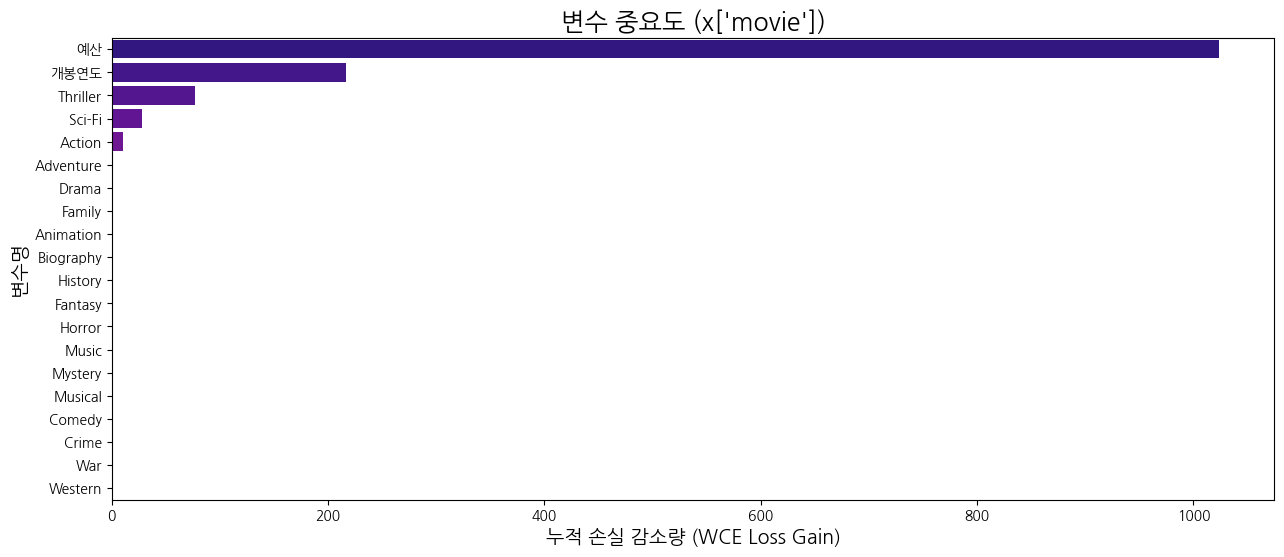

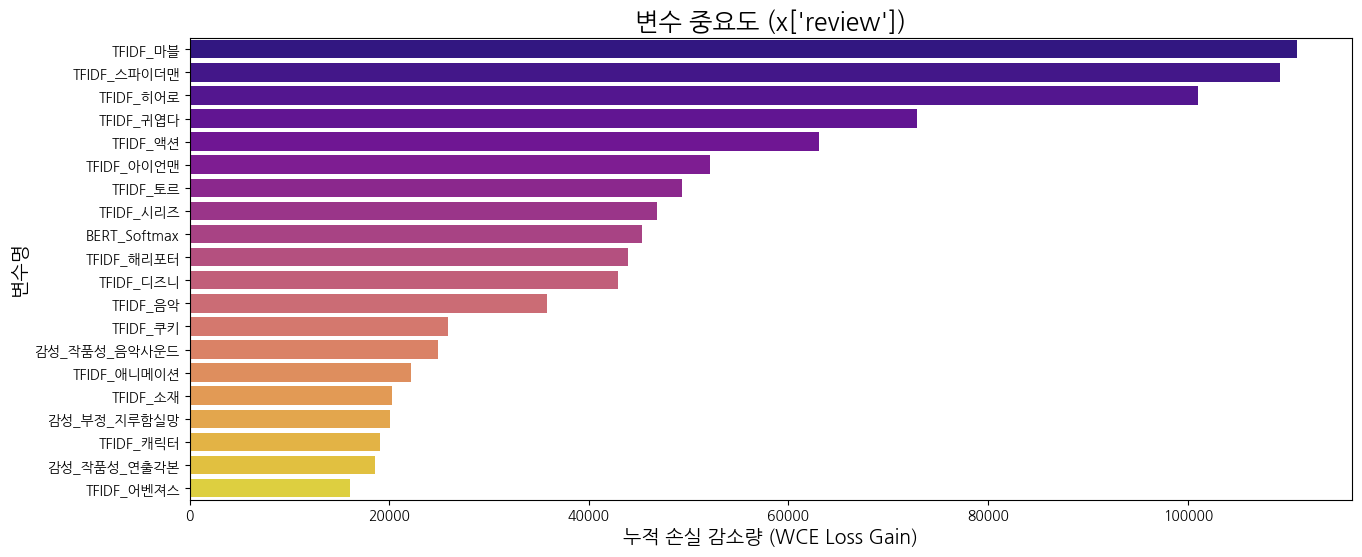

In [4]:
# ==================================================
# 해석: 변수 중요도
# ==================================================

# WCE Loss Gain 기반 변수 중요도
for i in x.keys():
    importance = pd.DataFrame({
        '변수명': models[f'{i}'].feature_name_,
        '변수 중요도': models[f'{i}'].feature_importances_
    }).sort_values(
        by = '변수 중요도', ascending = False
    ).reset_index(drop = True)

    # 상위 20개
    importance_top20 = importance.head(20)

    # 변수 중요도 시각화
    plt.figure(figsize = (15, 6))
    sns.barplot(
        x = importance_top20['변수 중요도'],
        y = importance_top20['변수명'],
        palette = 'plasma',
        hue = importance_top20['변수명'],
        legend = False
    )
    plt.title(f'변수 중요도 (x[\'{i}\'])', fontproperties = fontprop, fontsize = 18)
    plt.xlabel('누적 손실 감소량 (WCE Loss Gain)', fontproperties = fontprop, fontsize = 14)
    plt.ylabel('변수명', fontproperties = fontprop, fontsize = 14)
    plt.xticks(fontproperties = fontprop, fontsize = 10)
    plt.yticks(fontproperties = fontprop, fontsize = 10)
    plt.show()

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


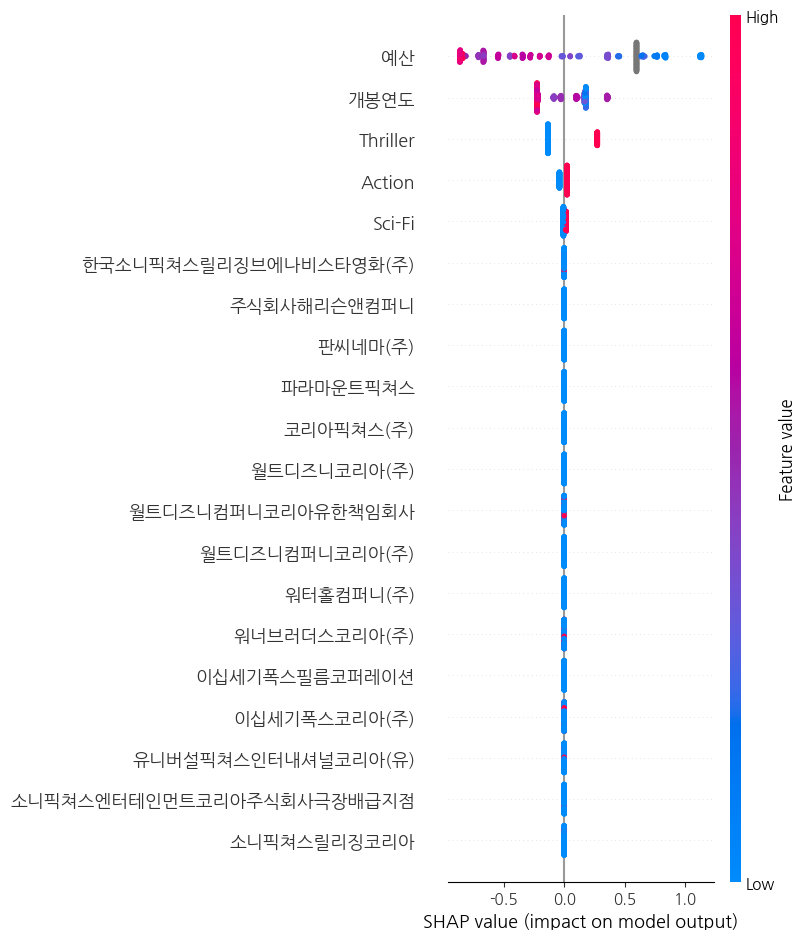

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


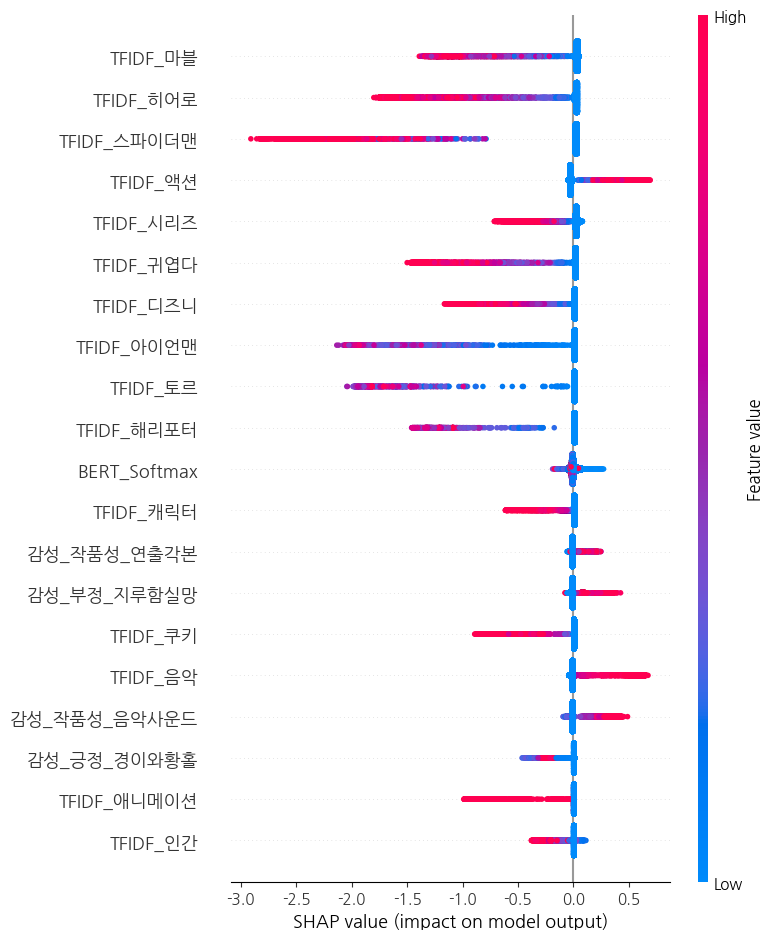

In [ ]:
# ==================================================
# 해석: SHAP
# ==================================================

# 한글 폰트 적용 (! ! ! 시스템에 설치되지 않은 글꼴 사용 불가능 ! ! !)
plt.rcParams['font.family'] = fontprop.get_name()

# SHAP 계산
for i in x.keys():
    explainer = shap.TreeExplainer(models[f'{i}'])
    shap_values = explainer.shap_values(x[f'{i}'])

    # SHAP 시각화
    shap.summary_plot(shap_values, x[f'{i}'], rng = 42, )